# KMeans 

## 데이터 불러오기와서 Dataframe
- 머신러닝 라이브러리인 sklearn에 있는 연습용 데이터셋 iris 데이터 불러오기
- 데이터 프레임을 위해 판다스 불러옴
- load_iris()는 미리 만들어둔 함수이고, 리턴값은 숨겨져 있다. 
- 아이리스 데이터 불러와서 변수 iris에 저장한다. 
- 아이리스 데이터를 표형태로 바꾸되, 컬럼값은 []에 있는 값으로

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


## KMeans

### fit 학습
- 3개 그룹으로 나누고 초기 중심점은 기본값 k-means++, 최대 300번 반복, 난수 0으로 고정  
- 아이리스 데이터 프레임을 KM으로 학습시킨다.  
- KM.labels_: KM에서 각 데이터가 어떤 군집에 속했는지 알려줄 것. 결과 자동으로 0부터 시작해서 3개 그룹 0,1,2나옴  

In [2]:
KM = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
KM.fit(iris_df) #훈련/테스트 분할x
KM.labels_ #각 데이터가 속한 군집 번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

### 군집번호 Df에 추가
- 실제정답은 target, 이값을 열에 추가
- 모델이 작업한 군집번호는 cluster, 이값을 열에 추가

In [3]:
iris_df['target'] = iris.target #실제값
iris_df['cluster'] = KM.labels_ #모델이 정한 군집번호
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


### 실제값과 생성된 그룹값 비교
- target은 실제값, cluster는 KMeans로 만들어낸 값. 
- targe별로 나누고 그안에서 다시 cluster로 쪼개서 소그룹 만들기
- sepal_length 꽃받침 길이 컬럼을 선택(개수 세기위한 목적)
- target은 이름표, cluster는 방번호이다. target 0인 50명 전부를 cluster1번에 모아놓음- 잘 골라냄  
- target1의 경우 50명중 47명만 cluster0번방에 모아놓음. 3명은 다른 방에 모임

In [4]:

iris_df.groupby(['target', 'cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

### 실루엣 점수
- 실루엣 점수 계산하는 도구 가져오기
- silhouette_samples함수는 데이터가 자기cluster안에 얼마나 잘 모여있고, 다른 군집과 얼마나 잘 떨어져 있는지 계산해서 데이터프레임에 열로 추가한다.
- 실루엣계수 결과 1에 가까우면 군집잘됨. 0에 가까우면 잘안됨

In [5]:
from sklearn.metrics import silhouette_score, silhouette_samples
iris_df['silhouette_coeff'] = silhouette_samples(iris.data, iris_df['cluster'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


### 실루엣 점수 평균값
- 아이리스 데이터에 클러스터 방번호불러와서 실루엣 계수 평균
- 0.7이상이면 거의 완벽, 0.5이상이면 괜찮음, 0.25~0.5는 그저 그렇다. 0.25 엉망

In [6]:
silhouette_score(iris.data, iris_df['cluster'])

0.5511916046195919

### 실루엣계수 뽑아서 변수에 저장

In [7]:
score_sample = silhouette_samples(iris.data, iris_df['cluster'])
score_sample

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

### 실루엣계수 시각화
- 바닥에 붙여서 하지 말고 살짝 띄워 10에서 시작  
- 3개의 방을 순서대로 1개씩 방문해서, 지금 방문중인 i번방에 소속된 실루엣계수만 골라내서 cluster_i에 저장
- cluster_i.sort()를 통해 오름차순으로 정렬
- y_upper는 바닥값 y_lower 10과 실루엣계수목록 수를 더한다. 이 목록은 인원수와 같다.
- barh는 가로 막대 그래프로 y값이 먼저나온다. y값범위, x값, label은 범례
- 다음그래프 시작점은 이전 천장 y_upper가 시작점
- range에서 마지막 숫자를 포함하지 않으므로 겹치지 않는다. 10, 60이면 10부터 59까지

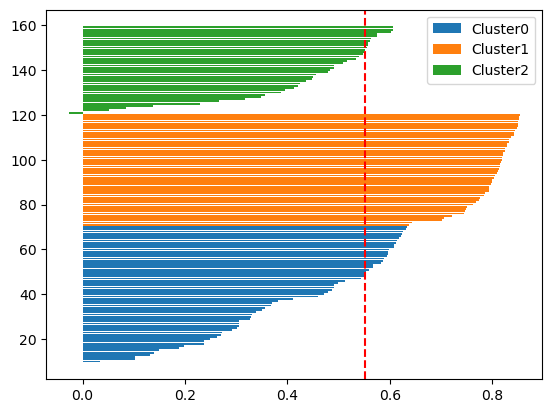

In [15]:
# 실루엣계수 시각화
import matplotlib.pyplot as plt
y_lower = 10

for i in range(3):
  cluster_i = score_sample[iris_df['cluster'] == i]
  cluster_i.sort()
  y_upper = y_lower + len(cluster_i)
  plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
  y_lower = y_upper
  
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--')
plt.legend()
plt.show()

In [9]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
sse_values = []

k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
  kmeans.fit(scree_df)
  sse_values.append(kmeans.inertia_)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

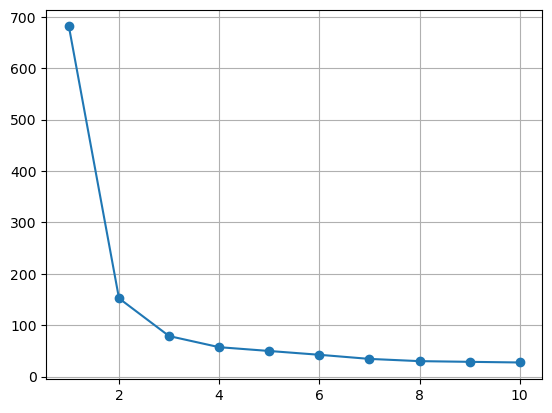

In [10]:
plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()

In [11]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [12]:
iris_df['pca_x'] = X_pca[:, 0]
iris_df['pca_y'] = X_pca[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


In [13]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,